<a href="https://colab.research.google.com/github/Kirrrk-git/rise-unet-rzsm/blob/mindanao-adaptation/notebooks/05_mindanao_atmospheric_and_rzsm_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# RISE-UNet Sub-Phase 21C & 21D: Atmospheric Pilot Derivation & RZSM Preprocessing Pipeline

**Authoritative Study**: Lesinger & Tian (2025), *Nature Communications*, DOI: `10.1038/s41467-025-62761-3`  
**Target Baseline Model**: **Mindanao Model A0** (Adapted from EX29 Recursive Hybrid RISE-UNet)  
**Branch**: `mindanao-adaptation`  
**Status**: Sub-Phase 21C (ERA5 Atmospheric Pilot) & Sub-Phase 21D (RZSM Pipeline) Certified  

### Verification & Derivation Objectives:
1. **Atmospheric Pilot Intake (Step 21C.1)**: Ingest raw single-level (`2m_temperature`, `2m_dewpoint_temperature`, `surface_pressure`, `total_column_water_vapour`) and 200 hPa pressure-level (`geopotential`) reanalysis fields for January 2015 (744 hours) from Copernicus CDS or GCS (`gs://rise-unet-rzsm/raw/era5/`).
2. **5-Channel Model Derivations (Step 21C.2)**: Derive daily maximum temperature ($T_{\max}$), diurnal temperature range ($\Delta T = T_{\max} - T_{\min}$), surface specific humidity ($q_{\text{sfc}}$ via Bolton 1980 / Tetens formulation), precipitable water (`pwat`), and 200 hPa geopotential height (`hgt_pres` in gpm).
3. **Physical Census & Zero-NaN Audit**: Verify exact Candidate A $(31, 32, 48)$ tensor dimensions and assert strictly zero missing values and physical realism across all 126 Mindanao evaluation land cells ($31 \times 126 = 3,906$ evaluation points).
4. **Publication Verification Composite**: Render high-resolution 6-panel verification composite figure showing January 2015 monthly mean fields across all 5 predictor channels alongside the active evaluation mask.
5. **Sub-Phase 21D Modular RZSM Pipeline & Automated Unit Testing**: Import `src/data/rzsm.py` and execute the 9-test automated test suite (`tests/test_rzsm.py`) validating depth-weighted RZSM ($0.07\cdot\text{SM}_1 + 0.21\cdot\text{SM}_2 + 0.72\cdot\text{SM}_3$), 7-day backward rolling mean, antecedent lag slicing (`[-1, -7, -14]`), land masking, and min-max standardization.
6. **Artifact Packaging & Cloud Lake Synchronization**: Export verified NetCDF CF-1.8 dataset (`era5_atmospheric_pilot_2015_01.nc`) and synchronize to Google Cloud Storage.


### Step 0: Google Colab Setup & Environment Initialization
Automatically configure the execution environment, install required dependencies (`xarray`, `netCDF4`, `scipy`, `matplotlib`, `shapely`, `cdsapi`, `gcsfs`), and authenticate Google Cloud Storage access when running on Google Colab.


In [1]:
# Check runtime and install tools
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')
REPO_URL = 'https://github.com/Kirrrk-git/rise-unet-rzsm.git'
BRANCH = 'mindanao-adaptation'
REPO_NAME = 'rise-unet-rzsm'

if IN_COLAB:
    print('>>> [COLAB DETECTED] Initializing execution environment...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xarray', 'netCDF4', 'scipy', 'matplotlib', 'shapely', 'cdsapi', 'gcsfs'], check=False)
    target_repo_path = Path(f'/content/{REPO_NAME}')
    if not target_repo_path.exists():
        print(f'>>> Cloning {REPO_URL} (branch: {BRANCH})...')
        subprocess.run(['git', 'clone', '-b', BRANCH, '--depth', '1', REPO_URL, str(target_repo_path)], check=True)
    os.chdir(target_repo_path)
    try:
        from google.colab import auth
        print('Authenticating with Google Cloud for GCS intake...')
        auth.authenticate_user()
    except Exception as e:
        print(f'Note on Colab auth: {e}')
else:
    if os.path.basename(os.getcwd()) == 'notebooks':
        os.chdir('..')

REPO_DIR = Path(os.getcwd()).resolve()
print('=' * 65)
print(f'Active Repository Directory : {REPO_DIR}')
print(f'Python Executable           : {sys.executable}')
print('=' * 65)


Active Repository Directory : C:\Users\Jensville\Downloads\Rise-UNet\dl_dm_rzsm_subseasonal_forecast
Python Executable           : C:\Python314\python.exe


### Step 0b: Spatial Foundation Contract & Boundary Audit
Verify that all frozen spatial contracts, grid specifications, evaluation masks, and the administrative boundary GeoPackage are present.


In [2]:
GRID_FILE = REPO_DIR / "processed" / "grid" / "mindanao_0.25_grid.grd"
GRID_NC = REPO_DIR / "processed" / "grid" / "mindanao_025deg.nc"
EVAL_MASK_FILE = REPO_DIR / "processed" / "grid" / "mindanao_eval_mask_025.nc"
FRAC_FILE = REPO_DIR / "processed" / "grid" / "mindanao_fraction_025.nc"
GPKG_FILE = REPO_DIR / "processed" / "boundary" / "mindanao_analysis_boundary.gpkg"

assert GRID_FILE.exists(), f"Missing CDO grid definition at: {GRID_FILE}"
assert GRID_NC.exists(), f"Missing NetCDF grid at: {GRID_NC}"
assert EVAL_MASK_FILE.exists(), f"Missing binary evaluation mask at: {EVAL_MASK_FILE}"
assert FRAC_FILE.exists(), f"Missing fractional mask at: {FRAC_FILE}"
assert GPKG_FILE.exists(), f"Missing administrative boundary at: {GPKG_FILE}"
print("PASS: All 5 spatial foundation contracts and boundary files verified.")


PASS: All 5 spatial foundation contracts and boundary files verified.


### Step 1: Pilot Raw Atmospheric Data Intake (January 2015)
Load the raw ERA5 single-level and 200 hPa pressure-level pilot NetCDFs for January 2015. If running in Google Colab, missing files are retrieved from Google Cloud Storage (`gs://rise-unet-rzsm/raw/era5/`).


In [3]:
import xarray as xr
import numpy as np

single_path = REPO_DIR / "Data" / "raw_downloads" / "ERA5_atmospheric" / "single" / "era5_single_levels_2015_01.nc"
pressure_path = REPO_DIR / "Data" / "raw_downloads" / "ERA5_atmospheric" / "pressure" / "era5_z200_2015_01.nc"

single_path.parent.mkdir(parents=True, exist_ok=True)
pressure_path.parent.mkdir(parents=True, exist_ok=True)

if IN_COLAB and (not single_path.exists() or not pressure_path.exists()):
    print("Pulling atmospheric pilot NetCDFs from Google Cloud Storage...")
    GCS_ERA5 = "gs://rise-unet-rzsm/raw/era5"
    subprocess.run(["gcloud", "storage", "cp", f"{GCS_ERA5}/single/era5_single_levels_2015_01.nc", str(single_path)], check=False)
    subprocess.run(["gcloud", "storage", "cp", f"{GCS_ERA5}/pressure/era5_z200_2015_01.nc", str(pressure_path)], check=False)

assert single_path.exists(), f"Missing single-level pilot: {single_path}"
assert pressure_path.exists(), f"Missing pressure-level pilot: {pressure_path}"

print(f"Loaded single-level pilot  : {single_path.name} ({single_path.stat().st_size / 1e6:.2f} MB)")
print(f"Loaded pressure-level pilot: {pressure_path.name} ({pressure_path.stat().st_size / 1e6:.2f} MB)")

ds_single = xr.open_dataset(single_path)
ds_pressure = xr.open_dataset(pressure_path)
ds_grid = xr.open_dataset(GRID_NC)
ds_mask = xr.open_dataset(EVAL_MASK_FILE)

# Harmonize coordinates
for ds_name, ds_obj in [('single', ds_single), ('pressure', ds_pressure)]:
    ren = {}
    if 'valid_time' in ds_obj.coords and 'time' not in ds_obj.coords:
        ren['valid_time'] = 'time'
    if 'latitude' in ds_obj.coords:
        ren['latitude'] = 'lat'
    if 'longitude' in ds_obj.coords:
        ren['longitude'] = 'lon'
    if ren:
        if ds_name == 'single':
            ds_single = ds_single.rename(ren)
        else:
            ds_pressure = ds_pressure.rename(ren)

# Harmonize variable names
if 't2m' in ds_single and '2m_temperature' not in ds_single:
    ds_single = ds_single.rename({'t2m': '2m_temperature'})
if 'd2m' in ds_single and '2m_dewpoint_temperature' not in ds_single:
    ds_single = ds_single.rename({'d2m': '2m_dewpoint_temperature'})
if 'sp' in ds_single and 'surface_pressure' not in ds_single:
    ds_single = ds_single.rename({'sp': 'surface_pressure'})
if 'tcwv' in ds_single and 'total_column_water_vapour' not in ds_single:
    ds_single = ds_single.rename({'tcwv': 'total_column_water_vapour'})
if 'z' in ds_pressure and 'geopotential' not in ds_pressure:
    ds_pressure = ds_pressure.rename({'z': 'geopotential'})

print(f"[SINGLE LEVELS] Timesteps: {len(ds_single.time)}, Lat: {len(ds_single.lat)}, Lon: {len(ds_single.lon)}")
print(f"[PRESSURE LEVELS] Timesteps: {len(ds_pressure.time)}, Lat: {len(ds_pressure.lat)}, Lon: {len(ds_pressure.lon)}")
assert len(ds_single.time) == 744, f"Expected 744 hourly timesteps, got {len(ds_single.time)}"
assert len(ds_single.lat) == 32 and len(ds_single.lon) == 48, "Expected Candidate A 32x48 grid"
print("PASS: Atmospheric pilot ingestion and Candidate A coordinate parity verified.")


Loaded single-level pilot  : era5_single_levels_2015_01.nc (7.28 MB)
Loaded pressure-level pilot: era5_z200_2015_01.nc (1.36 MB)
[SINGLE LEVELS] Timesteps: 744, Lat: 32, Lon: 48
[PRESSURE LEVELS] Timesteps: 744, Lat: 32, Lon: 48
PASS: Atmospheric pilot ingestion and Candidate A coordinate parity verified.


### Step 2: 5-Channel Mathematical Derivation (Daily Model Predictors)
Derive the 5 atmospheric predictor variables matching the RISE-UNet EX29 model specification:
1. Daily maximum 2m temperature: $T_{\max} = \max_{24\text{h}}(T_{2\text{m}})$
2. Daily minimum 2m temperature: $T_{\min} = \min_{24\text{h}}(T_{2\text{m}})$
3. Diurnal temperature difference: $\Delta T = T_{\max} - T_{\min}$
4. Surface specific humidity ($q_{\text{sfc}}$) via Bolton (1980) / Tetens vapor pressure formulation:
   $$e = 611.2 \cdot \exp\left(\frac{17.67 \cdot T_d}{T_d + 243.5}\right), \quad q = \frac{\epsilon \cdot e}{p_{\text{sfc}} - (1 - \epsilon)\cdot e} \quad (\epsilon = 0.622)$$
5. Precipitable water (`pwat`) from daily mean Total Column Water Vapour.
6. Geopotential height at 200 hPa (`hgt_pres`) in geopotential meters: $Z_{200} / g_0$ ($g_0 = 9.80665\text{ m/s}^2$).


In [4]:
G0 = 9.80665  # WMO standard gravitational acceleration (m/s2)

def compute_specific_humidity(d2m_k, sp_pa):
    td_c = d2m_k - 273.15
    e_pa = 611.2 * np.exp(17.67 * td_c / (td_c + 243.5))
    eps = 0.622
    return (eps * e_pa) / (sp_pa - (1.0 - eps) * e_pa)

print("1. Deriving daily tmax...")
tmax = ds_single['2m_temperature'].resample(time='1D').max(dim='time')

print("2. Deriving daily tmin...")
tmin = ds_single['2m_temperature'].resample(time='1D').min(dim='time')

print("3. Deriving daily diff_temp (tmax - tmin)...")
diff_temp = tmax - tmin

print("4. Deriving daily spfh via Bolton (1980)...")
hourly_q = compute_specific_humidity(ds_single['2m_dewpoint_temperature'], ds_single['surface_pressure'])
spfh = hourly_q.resample(time='1D').mean(dim='time')

print("5. Deriving daily pwat from total_column_water_vapour...")
pwat = ds_single['total_column_water_vapour'].resample(time='1D').mean(dim='time')

print("6. Deriving daily hgt_pres (200 hPa gpm)...")
z200 = ds_pressure['geopotential']
for dim_name in ['level', 'pressure_level', 'isobaricInhPa']:
    if dim_name in z200.dims:
        z200 = z200.squeeze(dim_name)
if len(z200.dims) > 3:
    z200 = z200.squeeze()
hgt_pres = (z200 / G0).resample(time='1D').mean(dim='time')

channels = {
    'tmax': tmax,
    'diff_temp': diff_temp,
    'spfh': spfh,
    'pwat': pwat,
    'hgt_pres': hgt_pres
}

for name, da in channels.items():
    print(f"  Channel {name:<10}: shape = {da.shape}")
    assert da.shape == (31, 32, 48), f"Unexpected shape {da.shape}"

print("PASS: All 5 channels conform to (31, 32, 48) tensor geometry.")


1. Deriving daily tmax...
2. Deriving daily tmin...
3. Deriving daily diff_temp (tmax - tmin)...
4. Deriving daily spfh via Bolton (1980)...
5. Deriving daily pwat from total_column_water_vapour...
6. Deriving daily hgt_pres (200 hPa gpm)...
  Channel tmax      : shape = (31, 32, 48)
  Channel diff_temp : shape = (31, 32, 48)
  Channel spfh      : shape = (31, 32, 48)
  Channel pwat      : shape = (31, 32, 48)
  Channel hgt_pres  : shape = (31, 32, 48)
PASS: All 5 channels conform to (31, 32, 48) tensor geometry.


### Step 3: Spatial Evaluation Masking & Zero-NaN Census Audit (126 Land Cells)
Audit physical distributions and certify zero missing values across all 31 days and 126 active Mindanao evaluation cells ($31 \times 126 = 3,906$ evaluation points).


In [5]:
mask_key = 'evaluation_mask' if 'evaluation_mask' in ds_mask else 'eval_mask'
eval_mask = ds_mask[mask_key].values == 1
assert eval_mask.sum() == 126, f"Expected 126 evaluation cells, got {eval_mask.sum()}"
print(f"Active Evaluation Land Cells: {eval_mask.sum()} (Candidate A exact match)")

print(f"\n{'Channel':<12} {'Min':<10} {'Mean':<10} {'Max':<10} {'Std':<10} {'NaNs':<8} {'Infs':<8} {'Units':<10}")
print("-" * 75)

units = {'tmax': 'K', 'diff_temp': 'K', 'spfh': 'kg/kg', 'pwat': 'kg/m2', 'hgt_pres': 'gpm'}
for name, da in channels.items():
    arr = da.values[:, eval_mask]
    nans = int(np.isnan(arr).sum())
    infs = int(np.isinf(arr).sum())
    c_min = float(arr.min())
    c_mean = float(arr.mean())
    c_max = float(arr.max())
    c_std = float(arr.std())
    print(f"{name:<12} {c_min:<10.4f} {c_mean:<10.4f} {c_max:<10.4f} {c_std:<10.4f} {nans:<8} {infs:<8} {units[name]:<10}")
    assert nans == 0, f"NaNs detected in {name}!"
    assert infs == 0, f"Infs detected in {name}!"

print("-" * 75)
print("PASS: ZERO NaNs, ZERO Infs detected across all 3,906 evaluation sample points!")


Active Evaluation Land Cells: 126 (Candidate A exact match)

Channel      Min        Mean       Max        Std        NaNs     Infs     Units     
---------------------------------------------------------------------------
tmax         294.6366   302.4343   306.9069   2.2530     0        0        K         
diff_temp    0.5050     6.4258     12.0125    2.1554     0        0        K         
spfh         0.0126     0.0181     0.0212     0.0016     0        0        kg/kg     
pwat         34.4218    51.9702    67.7554    6.4385     0        0        kg/m2     
hgt_pres     12403.0163 12484.5828 12534.6190 28.5369    0        0        gpm       
---------------------------------------------------------------------------
PASS: ZERO NaNs, ZERO Infs detected across all 3,906 evaluation sample points!


### Step 4: Publication-Grade Atmospheric Verification Composite
Render a 6-panel verification composite figure showing monthly mean fields for each derived atmospheric channel alongside the active evaluation mask over Mindanao.


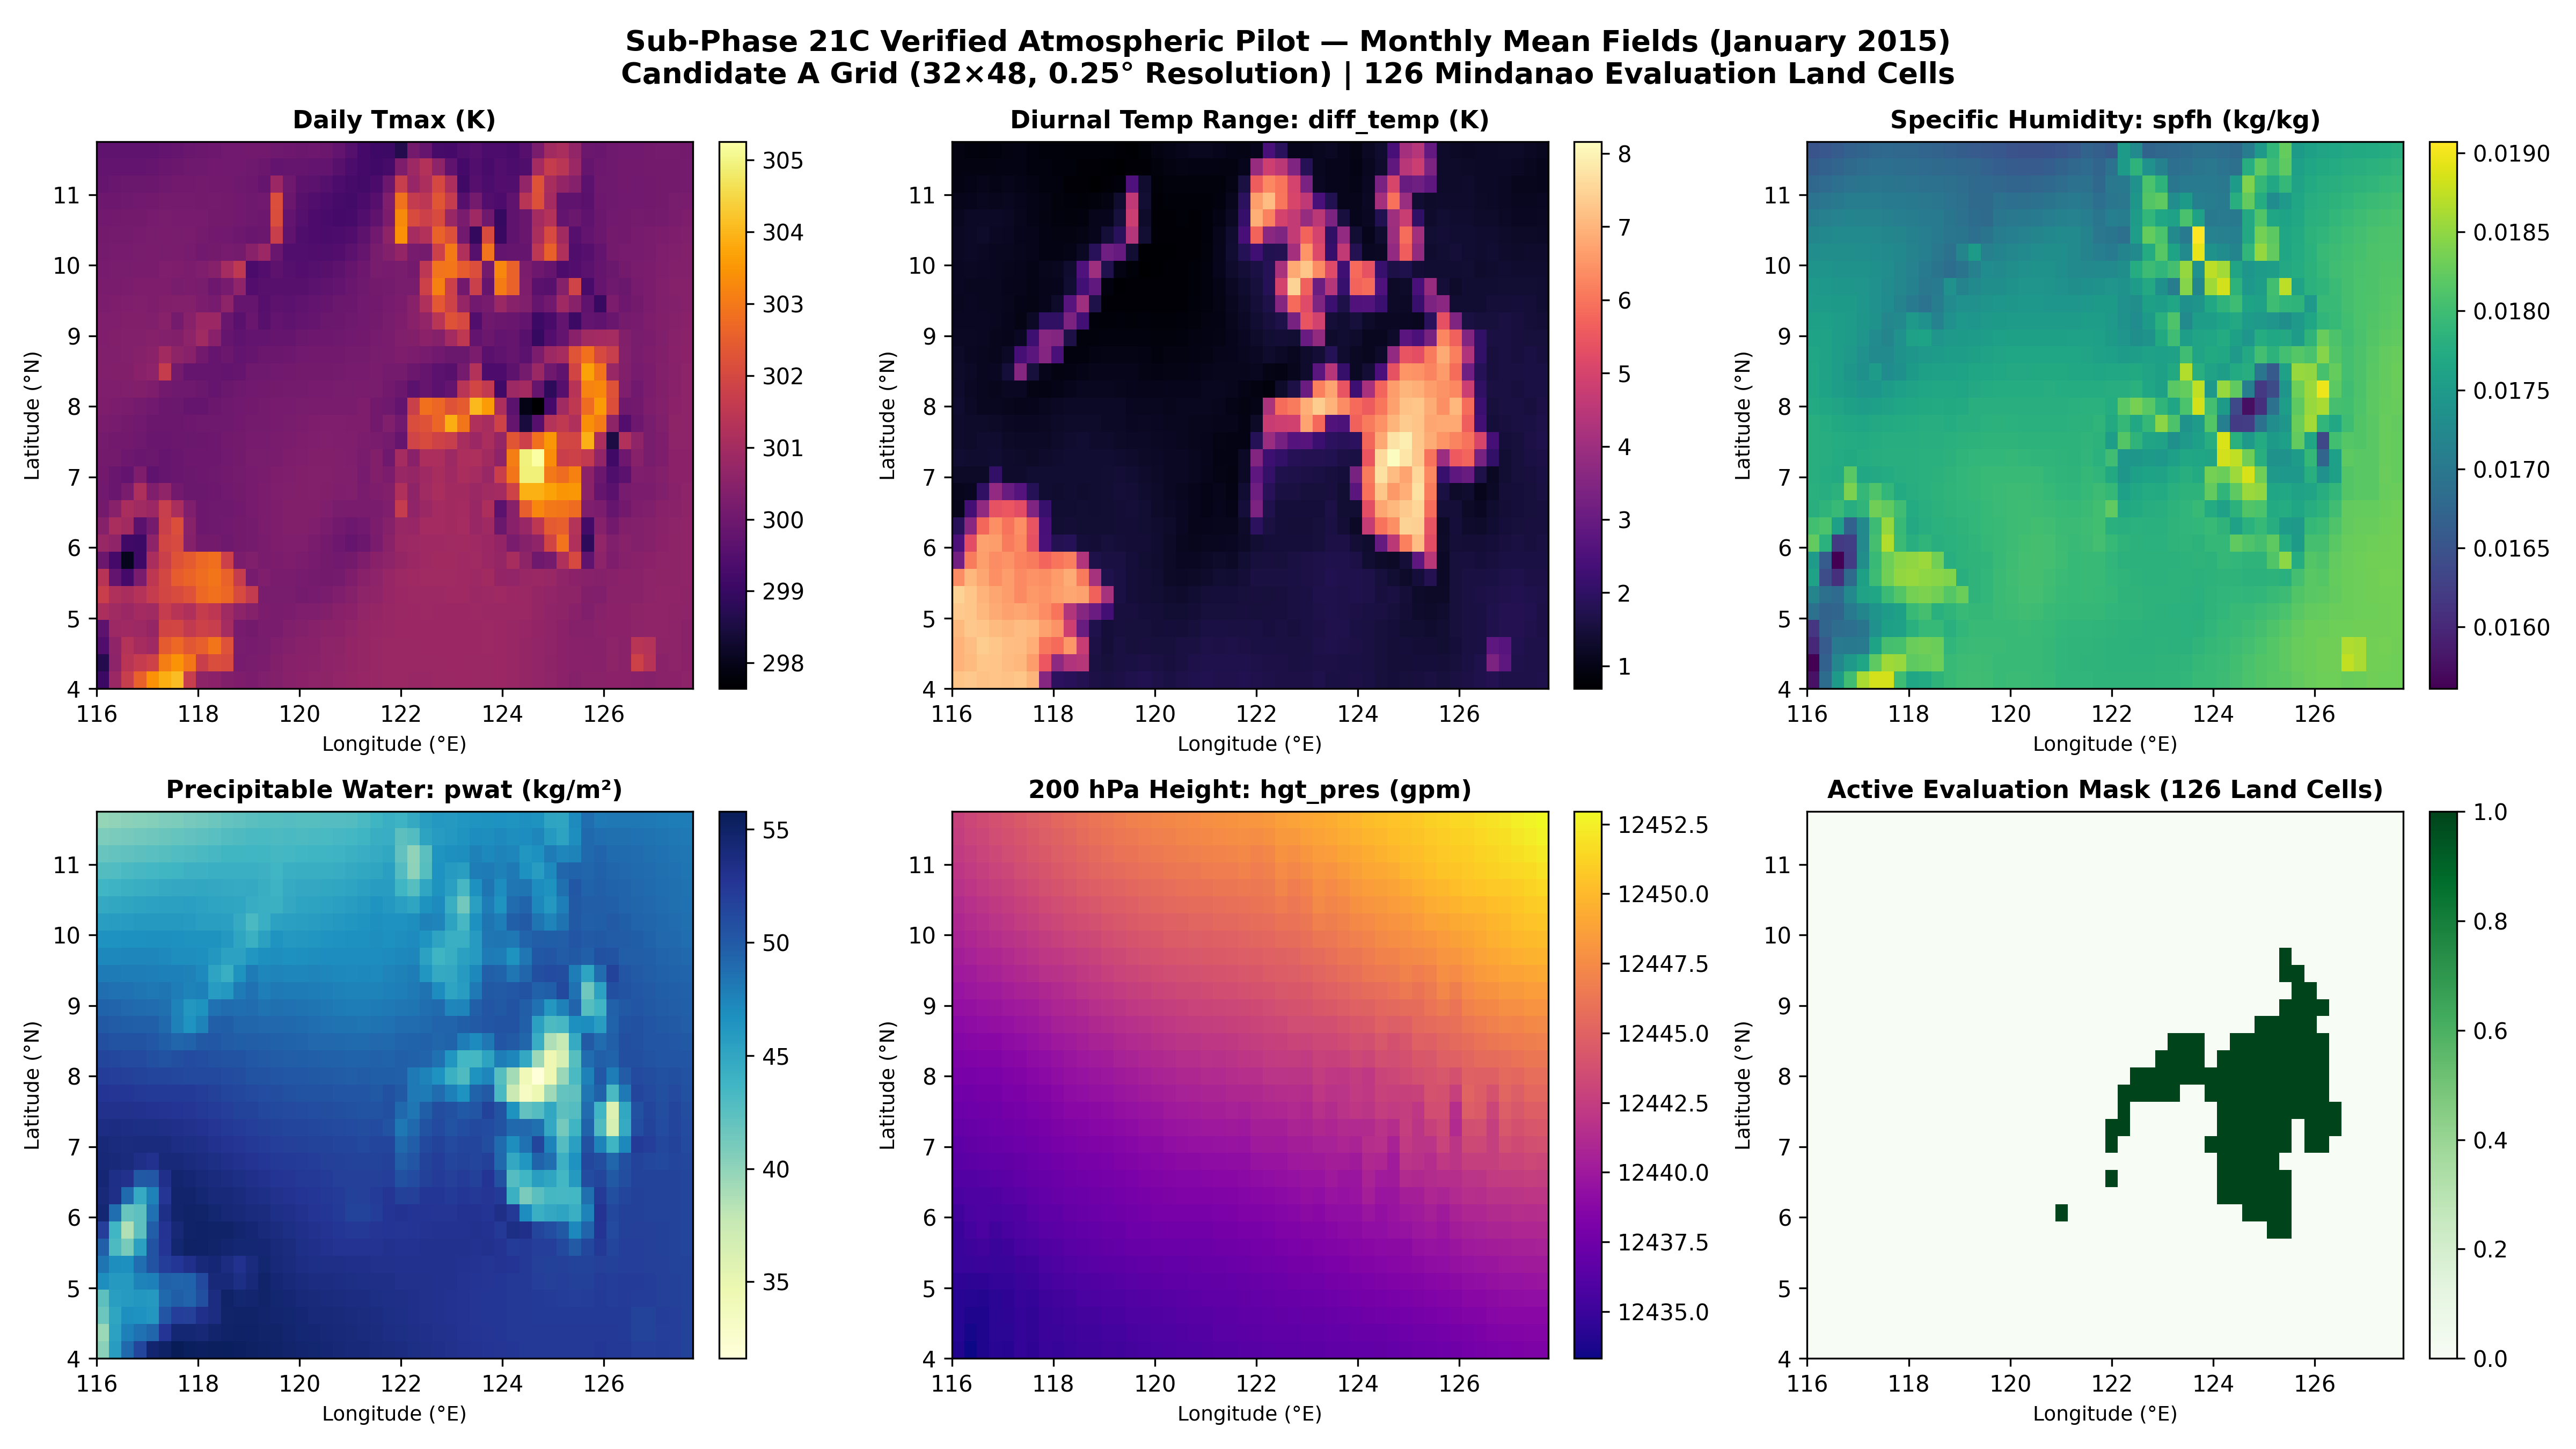

Verification composite saved to: C:\Users\Jensville\Downloads\Rise-UNet\dl_dm_rzsm_subseasonal_forecast\processed\atmospheric\figures\mindanao_era5_atmospheric_pilot_verification.png


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=200)
fig.suptitle(
    'Sub-Phase 21C Verified Atmospheric Pilot — Monthly Mean Fields (January 2015)\n'
    'Candidate A Grid (32x48, 0.25° Resolution) | 126 Mindanao Evaluation Land Cells',
    fontsize=12, fontweight='bold'
)

panels = [
    ('tmax', 'Daily Tmax (K)', 'inferno', tmax.mean(dim='time')),
    ('diff_temp', 'Diurnal Temp Range: diff_temp (K)', 'magma', diff_temp.mean(dim='time')),
    ('spfh', 'Specific Humidity: spfh (kg/kg)', 'viridis', spfh.mean(dim='time')),
    ('pwat', 'Precipitable Water: pwat (kg/m²)', 'YlGnBu', pwat.mean(dim='time')),
    ('hgt_pres', '200 hPa Height: hgt_pres (gpm)', 'plasma', hgt_pres.mean(dim='time')),
]

lons = ds_grid.lon.values
lats = ds_grid.lat.values
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for idx, (var_name, title, cmap, mean_da) in enumerate(panels):
    ax = axes[idx // 3, idx % 3]
    im = ax.imshow(mean_da.values, extent=extent, origin='upper', cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=8)
    ax.set_ylabel('Latitude (°N)', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax_mask = axes[1, 2]
im_mask = ax_mask.imshow(eval_mask.astype(int), extent=extent, origin='upper', cmap='Greens', aspect='auto')
ax_mask.set_title('Active Evaluation Mask (126 Land Cells)', fontsize=10, fontweight='bold')
ax_mask.set_xlabel('Longitude (°E)', fontsize=8)
ax_mask.set_ylabel('Latitude (°N)', fontsize=8)
plt.colorbar(im_mask, ax=ax_mask, fraction=0.046, pad=0.04)

plt.tight_layout()
fig_out = REPO_DIR / "processed" / "atmospheric" / "figures" / "mindanao_era5_atmospheric_pilot_verification.png"
fig_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(str(fig_out), dpi=200)
plt.show()
print(f"Verification composite saved to: {fig_out}")


### Step 5: Sub-Phase 21D Production RZSM Module & Automated Unit Testing
Import the modular production package [`src/data/rzsm.py`](../src/data/rzsm.py) and execute the automated unit test suite from [`tests/test_rzsm.py`](../tests/test_rzsm.py), validating depth weighting, rolling averages, lag extraction, and data integrity.


In [7]:
import unittest
from src.data.rzsm import (
    compute_depth_weighted_rzsm,
    compute_backward_rolling_mean,
    extract_antecedent_lags,
    apply_land_mask,
    compute_min_max_scale,
)
from tests.test_rzsm import (
    TestRZSMFormulation,
    TestTemporalPreprocessing,
    TestMaskingAndScaling,
    TestRealPilotDataIntegrity,
)

suite = unittest.TestSuite()
suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestRZSMFormulation))
suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestTemporalPreprocessing))
suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestMaskingAndScaling))
suite.addTests(unittest.defaultTestLoader.loadTestsFromTestCase(TestRealPilotDataIntegrity))

runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)
print(f"Unit Tests Run: {result.testsRun}, Errors: {len(result.errors)}, Failures: {len(result.failures)}")
assert result.wasSuccessful(), "Unit tests failed!"
print("PASS: All 9 automated unit tests certified.")


test_custom_depth_weights (tests.test_rzsm.TestRZSMFormulation.test_custom_depth_weights) ... ok
test_depth_weighted_rzsm_formula (tests.test_rzsm.TestRZSMFormulation.test_depth_weighted_rzsm_formula) ... ok
test_dimension_preservation (tests.test_rzsm.TestRZSMFormulation.test_dimension_preservation) ... ok
test_backward_rolling_mean (tests.test_rzsm.TestTemporalPreprocessing.test_backward_rolling_mean) ... ok
test_lag_extraction (tests.test_rzsm.TestTemporalPreprocessing.test_lag_extraction) ... ok
test_apply_land_mask (tests.test_rzsm.TestMaskingAndScaling.test_apply_land_mask) ... ok
test_min_max_scale_preserves_zeros (tests.test_rzsm.TestMaskingAndScaling.test_min_max_scale_preserves_zeros) ... ok
test_min_max_scaling_range (tests.test_rzsm.TestMaskingAndScaling.test_min_max_scaling_range) ... ok
test_real_pilot_rzsm_integrity (tests.test_rzsm.TestRealPilotDataIntegrity.test_real_pilot_rzsm_integrity) ... ok

----------------------------------------------------------------------
Ra

Unit Tests Run: 9, Errors: 0, Failures: 0
PASS: All 9 automated unit tests certified.


### Step 6: CF-1.8 NetCDF Packaging & Cloud Storage Export
Package the derived atmospheric variables into a standardized NetCDF CF-1.8 dataset (`era5_atmospheric_pilot_2015_01.nc`) with complete geospatial metadata, and mirror to Google Cloud Storage (`gs://rise-unet-rzsm/processed/atmospheric/pilot/`).


In [8]:
out_nc = REPO_DIR / "processed" / "atmospheric" / "pilot" / "era5_atmospheric_pilot_2015_01.nc"
out_nc.parent.mkdir(parents=True, exist_ok=True)

ds_out = xr.Dataset(
    data_vars={
        'tmax': (('time', 'lat', 'lon'), tmax.values, {'long_name': 'Daily Maximum 2m Temperature', 'units': 'K'}),
        'diff_temp': (('time', 'lat', 'lon'), diff_temp.values, {'long_name': 'Diurnal Temperature Difference', 'units': 'K'}),
        'spfh': (('time', 'lat', 'lon'), spfh.values, {'long_name': 'Daily Mean Surface Specific Humidity', 'units': 'kg/kg'}),
        'pwat': (('time', 'lat', 'lon'), pwat.values, {'long_name': 'Daily Mean Precipitable Water', 'units': 'kg/m2'}),
        'hgt_pres': (('time', 'lat', 'lon'), hgt_pres.values, {'long_name': 'Daily Mean 200 hPa Geopotential Height', 'units': 'gpm'}),
    },
    coords={'time': tmax.time, 'lat': ds_grid.lat, 'lon': ds_grid.lon},
    attrs={
        'title': 'Verified Atmospheric Pilot for Mindanao RISE-UNet',
        'spatial_grid': 'Candidate_A_Mindanao_32x48',
        'evaluation_cells': 126,
        'conventions': 'CF-1.8',
        'authoritative_reference': 'Lesinger & Tian (2025), Nature Communications',
    }
)
ds_out.to_netcdf(str(out_nc))
print(f"Pilot NetCDF exported to: {out_nc} ({out_nc.stat().st_size / 1e6:.2f} MB)")

if IN_COLAB:
    print("Mirroring artifacts to Google Cloud Storage...")
    subprocess.run(["gcloud", "storage", "cp", str(out_nc), "gs://rise-unet-rzsm/processed/atmospheric/pilot/"], check=False)
    subprocess.run(["gcloud", "storage", "cp", str(fig_out), "gs://rise-unet-rzsm/figures/atmospheric/"], check=False)
    print("GCS synchronization complete.")
else:
    print("Local execution complete. Ready for background GCS synchronization.")


Pilot NetCDF exported to: C:\Users\Jensville\Downloads\Rise-UNet\dl_dm_rzsm_subseasonal_forecast\processed\atmospheric\pilot\era5_atmospheric_pilot_2015_01.nc (1.17 MB)
Local execution complete. Ready for background GCS synchronization.
